In [9]:
import os
import timm
import cv2
from collections import Counter
import random
import seaborn as sns
from pathlib import Path
import pandas as pd
import torch
import torchvision
import time
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
import torchvision.models as models 
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD, Adam, AdamW
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report
import numpy as np
from PIL import Image
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from torch.utils.data import Subset
device = torch.device("cuda")

# take a first look at the dataset

In [10]:
datasetDir = Path("/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset")
trainDir = datasetDir / "train"
valDir = datasetDir / "val"
testDir = datasetDir / "test"
classes = []
for path in trainDir.iterdir():
    classes.append(path.name)
print("Dataset Classes : \n",classes)
classCounts = {}
for classname in classes:
    dir = trainDir / classname
    classCounts[classname] = len(list(dir.glob("*")))
print("Class Counts : \n",classCounts)

Dataset Classes : 
 ['DR', 'AMD', 'CSR', 'DRUSEN', 'CNV', 'NORMAL', 'MH', 'DME']
Class Counts : 
 {'DR': 2300, 'AMD': 2300, 'CSR': 2300, 'DRUSEN': 2300, 'CNV': 2300, 'NORMAL': 2300, 'MH': 2300, 'DME': 2300}


visualization

<Axes: >

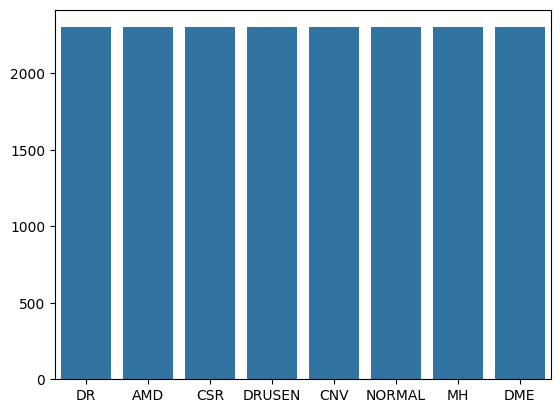

In [11]:
plt.plot()
sns.barplot(data=classCounts)        

seeing an image for test

Image mode :  RGB


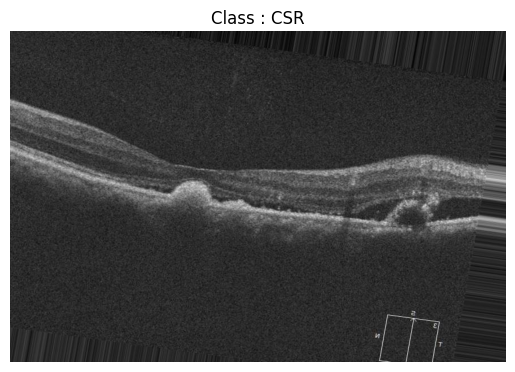

In [12]:
clss = random.choice(classes)
imagePath = random.choice(list((trainDir/clss).glob("*")))
image = Image.open(imagePath)
print("Image mode : ",image.mode)
plt.imshow(image, cmap ="gray")
plt.title(f"Class : {clss}")
plt.axis("off")
plt.show()

If the Image mode is L(gray scale), we should do one of these two:
1. Convert the scale to RGB (for using famous models)
2. Set the input channel of Conv2d of first layer in model to 1

Examining images's sizes

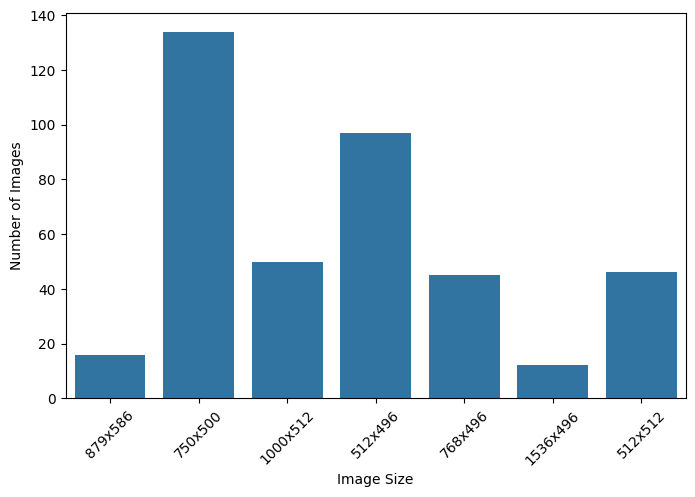

In [13]:
sizes = []
for cls in classes:
    images = list((trainDir/cls).glob("*"))
    for imagePath in images[:50]:
        image = Image.open(imagePath)
        sizes.append(image.size)
sizeCounts = Counter(sizes)
df = pd.DataFrame({
    "size": [f"{w}x{h}" for w,h in sizeCounts.keys()],
    "count": sizeCounts.values()
})
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="size",y="count")
plt.xlabel("Image Size")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

# Data Pipeline

label mapping

In [14]:
classToIndex = {}
for i, cls in enumerate(classes):
    classToIndex[cls] = i
print(classToIndex)
indexToClass = {}
for i,cls in enumerate(classes):
    indexToClass[i] = cls

{'DR': 0, 'AMD': 1, 'CSR': 2, 'DRUSEN': 3, 'CNV': 4, 'NORMAL': 5, 'MH': 6, 'DME': 7}


1. make a complete (imagePath,label) for every image in the dataset
2. split it into train and validation sets

In [15]:
trainPaths = []
trainlabels = []
for cls in classes:
    classFolder = trainDir / cls
    for imgPath in classFolder.glob("*"):
        trainPaths.append(imgPath)
        trainlabels.append(classToIndex[cls])
print("Total Number of images in train:", len(trainPaths))
dataSamples = random.sample(list(zip(trainPaths, trainlabels)), 3)
print("\nData Samples:", dataSamples)
validationPaths = []
validationLabels = []
for cls in classes:
    classFolder = valDir / cls
    for imgPath in classFolder.glob("*"):
        validationPaths.append(imgPath)
        validationLabels.append(classToIndex[cls])
print("Total Number of images in Validation:", len(validationPaths))

Total Number of images in train: 18400

Data Samples: [(PosixPath('/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/train/DME/dme_train_2246.jpg'), 7), (PosixPath('/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/train/MH/mh_train_1033.jpg'), 6), (PosixPath('/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/train/NORMAL/normal_train_2636.jpg'), 5)]
Total Number of images in Validation: 2800


## Define Dataset Class

In [16]:
class OCTDataset(Dataset):
    def __init__(self,imagePaths,labels,transform=None):
        super().__init__()
        self.imagePaths = imagePaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.imagePaths)
    
    def __getitem__(self, index):
        imagePath = self.imagePaths[index]
        label = self.labels[index]
        image = Image.open(imagePath).convert("L")
        if self.transform:
            image = self.transform(image)
        return image,label

Calculating mean and variance of the train and val datasets for normilization

In [17]:
trainTransform = transforms.Compose([
    transforms.Resize((224,512)),
    transforms.ToTensor(),
])

valTransform = transforms.Compose([
    transforms.Resize((224,512)),
    transforms.ToTensor(),
])

def mean_std(OCTDataset):
    images = []
    for image , _ in OCTDataset:
        images.append(image)
    images = torch.stack(images)
    mean = images.mean().item()
    std = images.std().item()
    return mean, std

trainDataset = OCTDataset(trainPaths,trainlabels,transform=trainTransform)
valDataset = OCTDataset(validationPaths,validationLabels,transform=valTransform)
trainMean, trainStd = mean_std(trainDataset)
valMean, valStd = mean_std(valDataset)

## transformers

In [18]:
trainTransform = transforms.Compose([
    transforms.Resize((224,512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[trainMean],std=[trainStd])
])

valTransform = transforms.Compose([
    transforms.Resize((224,512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[valMean],std=[valStd])
])

make Dataset and Dataloader

In [19]:
trainDataset = OCTDataset(trainPaths,trainlabels,transform=trainTransform)
valDataset = OCTDataset(validationPaths,validationLabels,transform = valTransform)
trainLoader = DataLoader(trainDataset,batch_size=32,shuffle=True,num_workers=4)
valLoader = DataLoader(valDataset,batch_size=128,shuffle=False,num_workers=4)

See a few images

[(750, 500),(768, 496),(750, 500),(512, 496),(1000, 512),(512, 496),(1000, 512),(512, 496),(750, 500),(750, 500)]

torch.Size([1, 224, 512])


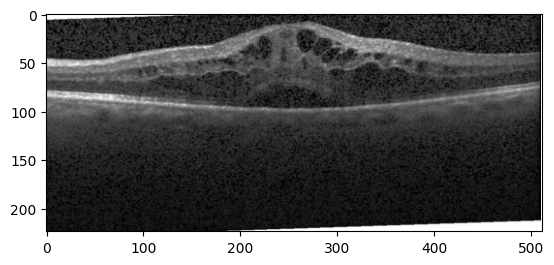

In [20]:
rand = random.randint(0,len(trainDataset))
image, label = trainDataset[rand]
print(image.shape)
plt.imshow(image.permute(1,2,0),cmap="gray")

# Building Vision Transformer Architecture

1. Patch Embedding

In [21]:
class PatchEmbedding(nn.Module):
    def __init__(self,image_size,in_channels,patch_size,embed_dim):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size[0] // patch_size) * (image_size[1] // patch_size)
        self.projection = nn.Conv2d(in_channels=in_channels,out_channels=embed_dim,kernel_size=patch_size,stride=patch_size)
        
    def forward(self, x):
        x = self.projection(x)
        x = x.flatten(2)
        x = x.transpose(1,2)
        return x

2. Multi-Head Self-Attention

In [22]:
class SelfAttention(nn.Module):

    def __init__(self, embed_dim):
        super().__init__()
        
        self.embed_dim = embed_dim
        self.qkv = nn.Linear(embed_dim,embed_dim * 3)
        self.projection = nn.Linear(embed_dim,embed_dim)

    def forward(self, x):
        qkv = self.qkv(x)
        q,k,v = qkv.chunk(3,dim=-1)
        attention = torch.softmax(((q @ k.transpose(-2,-1)) / (self.embed_dim ** 0.5)),dim=-1)
        output = attention @ v
        output = self.projection(output)
        return output

In [ ]:
class MultiHeadSelfAttention(nn.Module):

    def __init__(self,embed_dim,num_heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert (self.head_dim * num_heads == embed_dim)
        self.qkv = nn.Linear(embed_dim,3*embed_dim)
        self.projection = nn.Linear(embed_dim,embed_dim)

    def reshapeHeads(self,x):
        B,N,D = x.shape
        x = x.reshape(B,self.num_heads,N,self.head_dim)
        return x
    
    def forward(self,x):
        qkv = self.qkv(x)
        q,k,v = qkv.chunk(3,dim=-1)
        q = self.reshapeHeads(q)
        k = self.reshapeHeads(k)
        v = self.reshapeHeads(v)
        attention = torch.softmax(((q @ k.transpose(-2,-1)) / (self.embed_dim ** 0.5)),dim=-1)
        output = attention @ v
        output = output.transpose(1,2)
        output = output.flatten(2)
        output = self.projection(output)
        return output

3. MLP Block

In [24]:
class MLP(nn.Module):
    def __init__(self,embed_dim,hidden_dim,dropout=0.1):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim,hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim,embed_dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.mlp(x)

4. Encoder Block

In [25]:
class TransformerEncoderBlock(nn.Module):

    def __init__(self,embed_dim,num_heads,mlp_ratio=4,dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attention = MultiHeadSelfAttention(embed_dim,num_heads)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim,embed_dim * mlp_ratio,dropout)

    def forward(self, x):
        #Residual
        x = x + self.attention(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

5. Making The Final Vision Transform

In [26]:
class VisionTransformer(nn.Module):

    def __init__(self,image_size,patch_size,in_channels,num_classes,embed_dim,depth,num_heads,mlp_ratio=4,dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size,1,16,256)
        self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1,self.patch_embed.num_patches + 1,embed_dim))
        self.blocks = nn.Sequential(
            *[TransformerEncoderBlock(embed_dim,num_heads,mlp_ratio,dropout) for _ in range(depth)]
            )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim,num_classes)
        self.apply(self.initWeights)

    def initWeights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight,std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

        elif isinstance(m, nn.Conv2d):
            nn.init.trunc_normal_(m.weight,std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)


    def forward(self, x):
            # Patch Embedding
            x = self.patch_embed(x)
            # Adding CLS Token
            cls_tokens = self.cls_token.expand(x.shape[0],-1,-1)
            x = torch.cat((cls_tokens, x),dim=1)
            # Position Embedding
            x = x + self.pos_embed
            # Passing Through The Encoders
            x = self.blocks(x)
            x = self.norm(x)
            # Take CLS token
            x = x[:,0]
            # Final Classification Result in head
            x = self.head(x)
            return x

In [96]:
VisionTransformerModel = VisionTransformer((224,512),16,1,8,256,6,8,mlp_ratio=4,dropout=0.1)
VisionTransformerModel = VisionTransformerModel.to(device)
VisionTransformerModel = torch.nn.DataParallel(VisionTransformerModel)
parametersCount = 0
for param in VisionTransformerModel.module.parameters():
    parametersCount += param.numel()
print("Total Parameters Count : ",parametersCount)

Total Parameters Count :  4922120


# Training and Validating Model

## train and validatation functions

In [97]:
lossFunction = nn.CrossEntropyLoss(label_smoothing=0.1)
def train(model,trainLoader,optimizer):
    model.train()
    correct = 0
    total = 0
    TotalLoss = 0
    for images,labels in trainLoader:
        optimizer.zero_grad()
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        loss = lossFunction(output,labels)
        loss.backward()
        optimizer.step()
        pred = torch.argmax(output,dim=1)
        TotalLoss += loss.item()
        correct += (pred == labels).sum().item()
        total += labels.size(0)
    avgLoss = TotalLoss/len(trainLoader)
    accuracy = correct/total
    return avgLoss, accuracy

def validate(model,testLoader):
    model.eval()
    correct = 0
    total = 0
    targets = []
    predictions = []
    with torch.no_grad():
        for images, labels in testLoader:
            images = images.to(device)
            labels = labels.to(device)
            output = model(images)
            pred = torch.argmax(output,dim=1)
            correct += (pred == labels).sum().item()
            pred = pred.to("cpu")
            labels = labels.to("cpu")
            targets.extend(labels.numpy())
            predictions.extend(pred.numpy())
            total += labels.size(0)
    targets = np.array(targets)
    predictions = np.array(predictions)
    accuracy = correct/total
    return accuracy,targets, predictions

## Initial test of model on a very small subset of the dataset with only 32 images

In [ ]:
small_dataset = Subset(trainDataset,range(32))
smallLoader = DataLoader(small_dataset,batch_size=8,shuffle=True)
optimizer = AdamW(VisionTransformerModel.parameters(),lr=1e-4,weight_decay=0)
scheduler = CosineAnnealingLR(optimizer,T_max=20)
for epoch in range(1,21):
    AvgLoss, accuracy = train(VisionTransformerModel,smallLoader,optimizer)
    scheduler.step()
    print(f"Epoch {epoch}, AvgLoss : {AvgLoss:.6f}, Accuracy : {accuracy:.2f}")

Epoch 1, AvgLoss : 0.663732, Accuracy : 0.84
Epoch 2, AvgLoss : 0.066286, Accuracy : 1.00
Epoch 3, AvgLoss : 0.038997, Accuracy : 1.00
Epoch 4, AvgLoss : 0.030918, Accuracy : 1.00
Epoch 5, AvgLoss : 0.027012, Accuracy : 1.00
Epoch 6, AvgLoss : 0.024604, Accuracy : 1.00
Epoch 7, AvgLoss : 0.022890, Accuracy : 1.00
Epoch 8, AvgLoss : 0.021437, Accuracy : 1.00
Epoch 9, AvgLoss : 0.020336, Accuracy : 1.00
Epoch 10, AvgLoss : 0.019490, Accuracy : 1.00
Epoch 11, AvgLoss : 0.018789, Accuracy : 1.00
Epoch 12, AvgLoss : 0.018325, Accuracy : 1.00
Epoch 13, AvgLoss : 0.017738, Accuracy : 1.00
Epoch 14, AvgLoss : 0.017443, Accuracy : 1.00
Epoch 15, AvgLoss : 0.017300, Accuracy : 1.00
Epoch 16, AvgLoss : 0.017167, Accuracy : 1.00
Epoch 17, AvgLoss : 0.017139, Accuracy : 1.00
Epoch 18, AvgLoss : 0.016959, Accuracy : 1.00
Epoch 19, AvgLoss : 0.016875, Accuracy : 1.00
Epoch 20, AvgLoss : 0.016843, Accuracy : 1.00


# Train The Model

Epoch 1, Took 1.0 minutes and 36 seconds
Train AvgLoss : 1.377114	Train Accuracy : 0.45	Validation Accuracy : 0.53
Epoch 3, Took 1.0 minutes and 37 seconds
Train AvgLoss : 1.200603	Train Accuracy : 0.57	Validation Accuracy : 0.57
Epoch 4, Took 1.0 minutes and 36 seconds
Train AvgLoss : 1.158617	Train Accuracy : 0.61	Validation Accuracy : 0.60
Epoch 5, Took 1.0 minutes and 38 seconds
Train AvgLoss : 1.121709	Train Accuracy : 0.64	Validation Accuracy : 0.66
Epoch 6, Took 1.0 minutes and 36 seconds
Train AvgLoss : 1.076187	Train Accuracy : 0.67	Validation Accuracy : 0.67
Epoch 7, Took 1.0 minutes and 36 seconds
Train AvgLoss : 1.034542	Train Accuracy : 0.70	Validation Accuracy : 0.70
Epoch 8, Took 1.0 minutes and 36 seconds
Train AvgLoss : 0.989083	Train Accuracy : 0.72	Validation Accuracy : 0.73
Epoch 9, Took 1.0 minutes and 37 seconds
Train AvgLoss : 0.946860	Train Accuracy : 0.76	Validation Accuracy : 0.74
Epoch 10, Took 1.0 minutes and 37 seconds
Train AvgLoss : 0.909572	Train Accurac

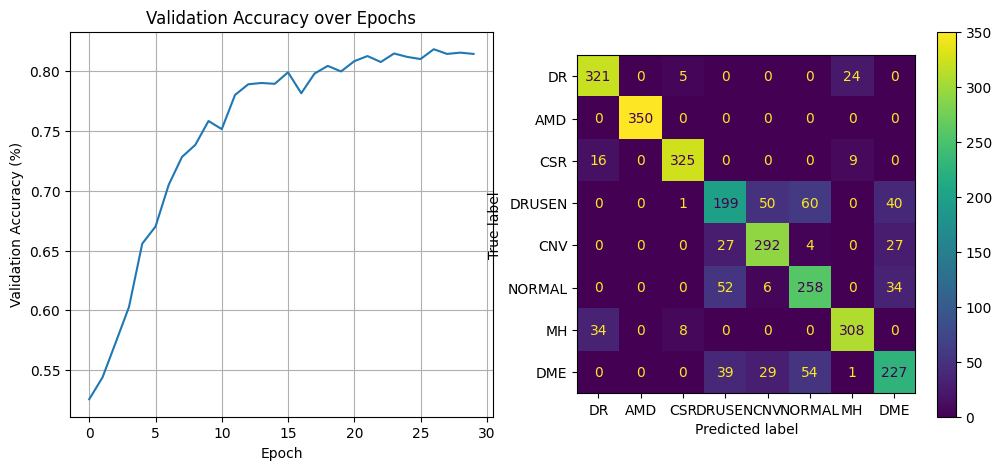


Checkpoint Saved


In [98]:
numOfEpochs = 30
optimizer = AdamW(VisionTransformerModel.parameters(),lr=5e-5,weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer,T_max=numOfEpochs)
history = []
for epoch in range(1,numOfEpochs+1):
    startTime = time.time()
    trainLoss, trainAcc = train(VisionTransformerModel,trainLoader,optimizer)
    epochTime = time.time() - startTime
    scheduler.step()
    if epoch < numOfEpochs:
        valAcc, _, _ = validate(VisionTransformerModel,valLoader)
        print(f"Epoch {epoch}, Took {epochTime//60} minutes and {epochTime%60:.0f} seconds")
        print(f"Train AvgLoss : {trainLoss:.6f}\tTrain Accuracy : {trainAcc:.2f}\tValidation Accuracy : {valAcc:.2f}")
        history.append(valAcc)
    else:
        valAcc ,targets, predictions = validate(VisionTransformerModel,valLoader)
        history.append(valAcc)
        print(f"Epoch {epoch}, Took {epochTime//60} minutes and {epochTime%60:.0f} seconds")
        print(f"Train AvgLoss : {trainLoss:.6f}\tTrain Accuracy : {trainAcc:.2f}\tValidation Accuracy : {valAcc:.2f}")
        print("\nFinal Statistic of model on Validation Data :")
        print(classification_report(targets,predictions,target_names=classes,digits=4))
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        ConfusionMatrixDisplay.from_predictions(targets,predictions,display_labels=classes,ax=axes[1])
        axes[0].plot(history)
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Validation Accuracy (%)")
        axes[0].set_title("Validation Accuracy over Epochs")
        axes[0].grid(True)
        plt.show()

torch.save(VisionTransformerModel.module.state_dict(),"/kaggle/working/VisionTransformerModel.pth")
print("\nCheckpoint Saved")
